In [23]:
import os
import json
import glob
import matplotlib.pyplot as plt

import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qaoa_training_pipeline.utils.graph_utils import load_graph, solve_max_cut, graph_to_operator
from qopt_best_practices.cost_function.cost_utils import counts_to_maxcut_cost
from qaoa_parameter_setting.utils.analysis import mean_obj, standard_error_mean

In [24]:
depth   = 5        # depth value
num_files   = 10   # number of files 


# instance = "_30nodes_random3regular.json"
# short_name = "N30R3R"
# folder = "random_regular"
instance = "_7_3_heavyhex_144nodes_weighted.json"
short_name = "N144HH73"
folder = "heavy_hex"
# instance = "_40nodes_erdosrenyi20percent.json"
# short_name = "N40ER20"
# folder = "erdos_renyi"
# instance = "_100nodes_2swap_layers.json"
# short_name = "N100L2S2"
# folder = "line_to_full"

all_summaries = []
matches = []
for n in range(num_files):
    prefix = f"data/hardware/{folder}/00{n}{short_name}_{depth}"
    found = glob.glob(prefix + "*.json")
    matches.extend(found)

In [25]:
def load_json(partial_name, directory="."):

    pattern = os.path.join(directory, f"*{partial_name}*.json")
    matches = glob.glob(pattern)

    if not matches:
        raise FileNotFoundError(f"No JSON files found matching: {partial_name}")

    with open(matches[0], "r") as f:
        data = json.load(f)
    return data

In [26]:
result_repo=f"../QAOA-Parameter-Setting/data/training/{folder}"
max_cuts=[]
min_cuts=[]
ar_diffs=[]
for n in range(num_files):
    data = load_json(f"00{n}{short_name}_MC", directory=result_repo)
    cost_op = SparsePauliOp.from_list(data["cost_operator"])
    max_cut, min_cut, ar = solve_max_cut(cost_op,  data["1"]["energy"])
    ar_diff= ar*(max_cut-min_cut)- data["1"]["energy"]
    max_cuts.append(max_cut)
    min_cuts.append(min_cut)
    ar_diffs.append(ar_diff)
    print(n)

0
1
2
3
4
5
6
7
8
9


In [27]:
all_methods = []
file_data   = []

for fname in matches:
    try:
        with open(fname, "r") as fin:
            res_summary = json.load(fin)

        methods = set()
        energies = {}
        basename = os.path.basename(fname)   # '001N40R3R_3_d4kbkgqv0j9c73e46o50.json'
        prefix_digits = ''.join([c for c in basename if c.isdigit()][:3])  
        n = int(prefix_digits)
        graph = load_graph(f"instances/{folder}/00{n}{instance}")
        mc_costs = [counts_to_maxcut_cost(graph, res["counts"]) for res in res_summary]
        means = [100*(mean_obj(mc_cost)-min_cuts[n])/(max_cuts[n]-min_cuts[n]) for mc_cost in mc_costs]
        sems = np.array([100*(standard_error_mean(mc_cost, sum(res_summary[idx]["counts"].values())))/(max_cuts[n]-min_cuts[n]) for idx, mc_cost in enumerate(mc_costs)])
        for idx, mc_cost in enumerate(mc_costs):
            try:
                label =res_summary[idx]["metadata"]["circuit_metadata"]["method"]
                val   = res_summary[idx]["metadata"]["circuit_metadata"]["eval_energy"]  
                methods.add(label)
                energies.setdefault(label, []).append([val,means[idx],sems[idx]])
            except (KeyError, TypeError):
                continue

        all_methods.append(methods)
        file_data.append(energies)

    except FileNotFoundError:
        print(f"Missing file: {fname}")
    print(n)

# Find shared labels
shared_labels = set.intersection(*all_methods)
print("Shared labels:", shared_labels)

# Collect energies per label 
energy_dict = {label: [] for label in shared_labels}
for energies in file_data:
    for label in shared_labels:
        if label in energies:
            energy_dict[label].append(energies[label])

0
1
2
3
4
5
6
7
8
9
Shared labels: {'TQA_MPS_opt_5', 'I_MPSAer_10', 'TQA_PP_opt_5', 'FA_PP_opt_5', 'F_MPS_10', 'F_PP_10', 'FA_MPSAer_opt_5', 'F_MPSAer_10', 'I_MPS_10', 'TQA_MPSAer_opt_5', 'I_PP_10'}


In [28]:
prefix_map = {
    "F": ["FOURIER", 0],
    "FA": ["fixed angles", 1],
    "I": ["INTERP", 2],
    "TQA": ["TQA", 3]
}

evaluator_map = {
    "MPSAer": 0,
    "MPS":0,
    "PP": 1,
   
}
def expand_abbreviation(abbr, prefix_map, depth):
    parts = abbr.split('_')
    if parts[2]=="opt":
        expanded= f"reoptmized {prefix_map[parts[0]][0]} with {parts[1]}"
    else:
        expanded= f"{prefix_map[parts[0]][0]} with {parts[1]}"
    return expanded



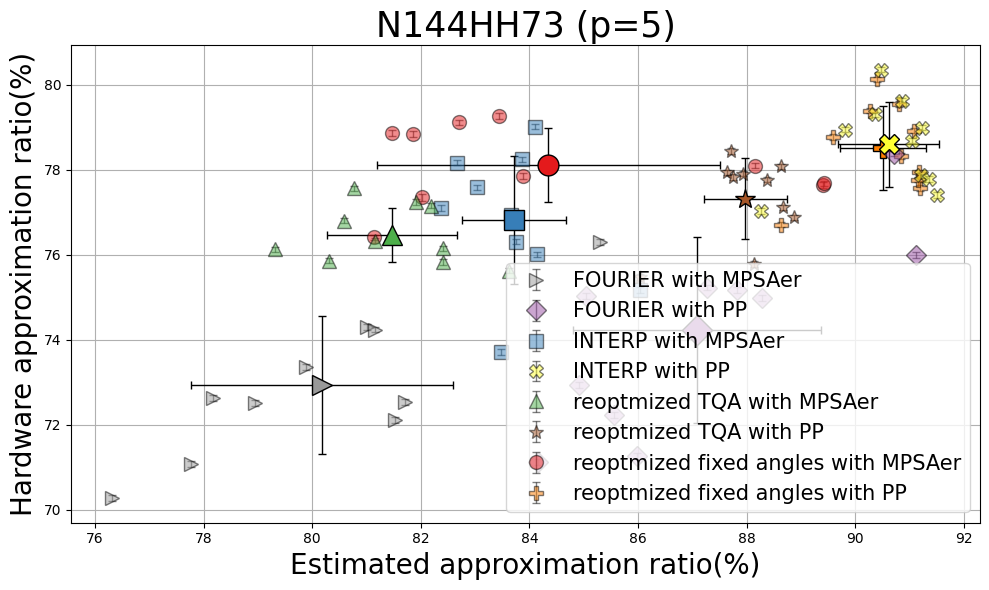

In [30]:
eval_list=["MPSAer", "PP"]

opts = { "mec": "k", "ecolor": "k", "capsize": 3, "elinewidth": 1}
fig=plt.figure(figsize=(10, 6))
colors = plt.cm.Set1.colors
marker_styles = ["o", "s", "^", "D", "P", "X", "*", "v", "<", ">"]

for i, label in enumerate(shared_labels):
    parts = label.split('_')
    if parts[1] in eval_list:
        ind=evaluator_map[parts[1]]*4+prefix_map[parts[0]][1]-1
        arr = np.array(energy_dict[label]) 
        arr0 =(arr[:, 0, 0]+np.array(ar_diffs).T)/(np.array(max_cuts).T-np.array(min_cuts).T)
        plt.errorbar(100*arr0.flatten(), arr[:, 0, 1], yerr=arr[:, 0, 2], fmt=marker_styles[ind],
                     label=expand_abbreviation(label, prefix_map, depth), linestyle="none",
                     color=colors[ind % len(colors)],alpha=0.5, ms=10,
                     **opts)
        plt.errorbar(np.average(100*arr0.flatten()), np.average(arr[:, 0, 1]), xerr=np.std(100*arr0.flatten()), yerr=np.std(arr[:, 0, 1]), fmt=marker_styles[ind],
                      linestyle="none",
                     color=colors[ind % len(colors)], ms=15, **opts)

plt.xlabel("Estimated approximation ratio(%)",fontsize=20)
plt.ylabel("Hardware approximation ratio(%)",fontsize=20)
plt.title(f"{short_name} (p={depth})",fontsize=25)
handles, labels = plt.gca().get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda x: x[0]))

# plt.legend(
#     fontsize=15,
#     loc="upper center",
#     bbox_to_anchor=(0.5, -0.20),  
#     ncol=3,
#     borderaxespad=0
# )

plt.legend(handles, labels, fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()
fig.savefig(f"{short_name}_{depth}_HW_r.pdf", bbox_inches="tight")

In [21]:
import pandas as pd
from scipy import stats
import scikit_posthocs as sp

data_est={}
data_hw={}
for i, label in enumerate(shared_labels):
    arr = np.array(energy_dict[label])
    arr0 =(arr[:, 0, 0]+np.array(ar_diffs).T)/(np.array(max_cuts).T-np.array(min_cuts).T)
    data_est[label]= 100*arr0.flatten()
    data_hw[label]= arr[:, 0, 1]
    
def compact_method_label(label, index=None):
    parts = label.split('_')
    if len(parts) < 2:
        return label
    method, evaluator = parts[0], parts[1]
    star = '^\star' if len(parts)>2 else ''
    prefix = f"{index}. " if index is not None else ''
    return f"{prefix}({method}, {evaluator}){star}"


def dataset_test(data, depth, label="Dataset"):

    method_name=f"Methods(p={depth})"
    # Build DataFrame
    df = pd.DataFrame({
        'score': np.concatenate(list(data.values())),
        method_name: sum([[m]*len(v) for m,v in data.items()], [])
    })

    # Kruskal–Wallis test
    groups = [df.loc[df[method_name]==m, 'score'] for m in data.keys()]
    H, p = stats.kruskal(*groups)

    df[method_name] = df[method_name].str.rsplit("_", n=1).str[0]

    # Medians for ordering
    group_medians = df.groupby(method_name)['score'].median()

    # Conover–Iman posthoc with Holm correction
    conover_results = sp.posthoc_conover(
        df, val_col='score', group_col=method_name, p_adjust='holm'
    )

    # Order rows/cols by descending median
    order = group_medians.sort_values(ascending=False).index
    results = conover_results.loc[order, order]
    
    # Apply upper-triangular mask (remove symmetric duplicates)
    results_ut = results.copy().astype("object")
    n = results_ut.shape[0]
    for i in range(n):
        for j in range(n):
            if i >= j:
                results_ut.iat[i, j] = ""   

    # Add median column (preserving order)
    results_ut["Median"] = group_medians[order]
    results_ut.index.name = None
    
    renamed = {
        name: compact_method_label(name, index=i+1)
        for i, name in enumerate(order)
    }
    results_ut.rename(index=renamed, inplace=True)
    results_ut.columns = [f"{i}." for i in range(1, len(results_ut.columns))] + ["Median"]
    results_ut.columns.name = method_name

    # Print summary
    print(f"\nKruskal–Wallis omnibus test on {label}: H={H:.3f}, p={p:.3e}")
    print(f"\nConover–Iman test (Holm correction) on {label}:\n", results_ut)

    return H, p, results_ut

# Run for both datasets
H_est, p_est, est_results = dataset_test(data_est,depth, label="estimated ratios")
H_hw, p_hw, hw_results   = dataset_test(data_hw,depth, label="hardware ratios")






Kruskal–Wallis omnibus test on estimated ratios: H=63.989, p=2.400e-11

Conover–Iman test (Holm correction) on estimated ratios:
 Methods(p=5)           1.   2.        3.        4.        5.        6.  \
1. (I, PP)                 1.0  0.001156  0.000211       0.0       0.0   
2. (FA, PP)^\star               0.003655  0.000862       0.0       0.0   
3. (TQA, PP)^\star                             1.0  0.001002   0.00186   
4. (F, PP)                                          0.004002  0.006906   
5. (I, MPSAer)                                                     1.0   
6. (FA, MPSAer)^\star                                                    
7. (TQA, MPSAer)^\star                                                   
8. (F, MPSAer)                                                           

Methods(p=5)                  7.        8.     Median  
1. (I, PP)                   0.0       0.0  90.951821  
2. (FA, PP)^\star            0.0       0.0  90.829378  
3. (TQA, PP)^\star           0.0  

In [22]:
import pandas as pd
import re

def p_to_colored_cell(p):
    """Return a LaTeX \\cellcolor based on p-value (no stars)."""
    if p == "" or pd.isna(p):
        return "--"

    p = float(p)

    if p < 0.001:
        return f"{{\\cellcolor[HTML]{{00441B}}}} \\color[HTML]{{F1F1F1}} {p:.2e}"
    elif p < 0.01:
        return f"{{\\cellcolor[HTML]{{309950}}}} \\color[HTML]{{F1F1F1}} {p:.2e}"
    elif p < 0.05:
        return f"{{\\cellcolor[HTML]{{B5E1AE}}}} \\color[HTML]{{000000}} {p:.2e}"
    else:
        return f"{p:.2e}"


def colorize_df(df):
    df_colored = df.copy().astype("object")
    for col in df.columns[:-1]:
        df_colored[col] = df[col].apply(p_to_colored_cell)
    return df_colored

def df_to_latex_with_hlines(df):
    latex = df.to_latex(
        escape=False,
        float_format="%.3g",
        index=True,
        index_names=True,
        na_rep="--",
        column_format="l" + "c"*(df.shape[1]),
 
    )
    latex = (latex
             .replace("\\toprule","\\hline\n")
             .replace("\\midrule","\\hline\n")
             .replace("\\bottomrule","\\hline\n")
             .replace("_","\\_"))
    # latex = latex.replace("\\\\\n", "\\\\ \\hline\n")
    # latex = re.sub(r"(\\begin\{tabular\}\{.*?\}\n)", r"\1\\hline\n", latex)
    return latex


# Export both tables
est_colored = colorize_df(est_results)
hw_colored = colorize_df(hw_results)

est_latex = df_to_latex_with_hlines(est_colored)
hw_latex = df_to_latex_with_hlines(hw_colored)

latex_code = (
    "\\begin{table}[ht]\n"
    "\\centering\n"
    "\\resizebox{\\columnwidth}{!}{%\n" +
    est_latex +
    "}\n"
    "\\vspace{0.5em}\n\n"
    "\\resizebox{\\columnwidth}{!}{%\n" +
    hw_latex +
    "}\n"+
    "\\caption{Conover–Iman's post-hoc test with Holm correction on estimated(top) and hardware(bottom) ratios generated from}\n"+
    "\\end{table}"
)

print(latex_code)


\begin{table}[ht]
\centering
\resizebox{\columnwidth}{!}{%
\begin{tabular}{lccccccccc}
\hline

Methods(p=5) & 1. & 2. & 3. & 4. & 5. & 6. & 7. & 8. & Median \\
\hline

1. (I, PP) & -- & 1.00e+00 & {\cellcolor[HTML]{309950}} \color[HTML]{F1F1F1} 1.16e-03 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 2.11e-04 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 9.12e-11 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 2.48e-10 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.46e-16 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 3.75e-18 & 91 \\
2. (FA, PP)^\star & -- & -- & {\cellcolor[HTML]{309950}} \color[HTML]{F1F1F1} 3.66e-03 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 8.62e-04 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 4.89e-10 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.31e-09 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 7.92e-16 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.95e-17 & 90.8 \\
3. (TQA, PP)^\star & -- & -- & -- & 1.00e+00 & {\ce